## Curso: MACHINE LEARNING CLASIFICACIÓN Y REGRESIÓN

## Unidad 1: Técnicas de validación de datos

🧩 Objetivo

- Exploración básica (nulos, detección simple de outliers)
- Split de datos
- Entrenamiento de un modelo
- Evaluación de overfitting / underfitting

**Dataset**: Iris

Fue introducido en 1936 por el estadístico y biólogo Ronald A. Fisher en un estudio sobre la diferenciación de especies de flores.

Incluye 150 observaciones de flores del género Iris, divididas en 3 especies:

- Iris setosa
- Iris versicolor
- Iris virginica

Para cada flor se registran 4 características numéricas:

- Largo del sépalo (sepal length)
- Ancho del sépalo (sepal width)
- Largo del pétalo (petal length)
- Ancho del pétalo (petal width)

Todas las medidas están en centímetros.

El objetivo típico es predecir la especie de la flor a partir de esas cuatro medidas.

En términos de machine learning:

Variables predictoras (features): medidas del sépalo y pétalo
Variable objetivo (target): especie de Iris

## Importación de librerias

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Carga de datos

In [2]:
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df["species"] = iris.target

In [3]:
df.shape

(150, 5)

In [4]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [7]:
df.species.value_counts()

,count
species,
0,50
1,50
2,50


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [9]:
# Resumen estadístico de las variables numéricas
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


## Detección de valores nulos

In [10]:
df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
species,0


El dataset Iris no tiene nulos, pero en un caso real se podría hacer:

`df.fillna(df.mean(), inplace=True)`

## Detección de outliers

Usamos boxplots.

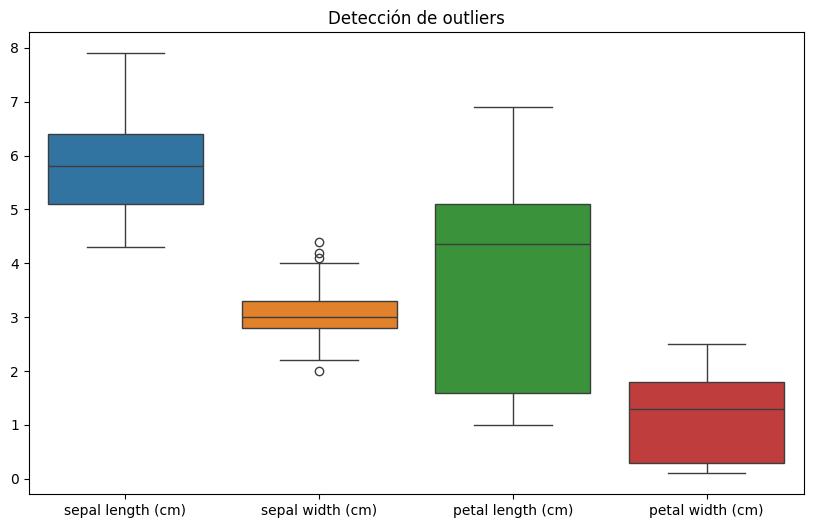

In [11]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df.iloc[:,:4])
plt.title("Detección de outliers")
plt.show()

Otra forma: IQR

In [12]:
Q1 = df.iloc[:,:4].quantile(0.25)
Q3 = df.iloc[:,:4].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df.iloc[:,:4] < (Q1 - 1.5*IQR)) | (df.iloc[:,:4] > (Q3 + 1.5*IQR)))

print("Cantidad de posibles outliers:")
print(outliers.sum())

Cantidad de posibles outliers:
sepal length (cm)    0
sepal width (cm)     4
petal length (cm)    0
petal width (cm)     0
dtype: int64


Para simplificar el ejemplo no eliminaremos outliers porque Iris tiene pocos.

## Separar variables predictoras y target

In [13]:
X = df.drop("species", axis=1)
y = df["species"]

## Split de datos

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2, # 80/20
    random_state=42,
    stratify=y # mantiene proporción de clases
)

## Entrenar modelo

In [15]:
model = DecisionTreeClassifier(
    max_depth=2,
    random_state=42
)

model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=2, random_state=42)

## Predicciones

In [16]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

## Evaluación del modelo

In [17]:
train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)

print("Accuracy entrenamiento:", train_acc)
print("Accuracy test:", test_acc)

Accuracy entrenamiento: 0.9666666666666667
Accuracy test: 0.9333333333333333


In [18]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



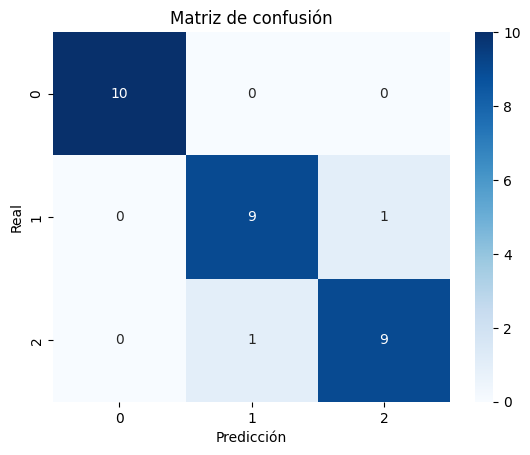

In [19]:
cm = confusion_matrix(y_test, y_pred_test)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión")
plt.show()

## Evaluar Overfitting o Underfitting

In [20]:
print("Train accuracy:", train_acc)
print("Test accuracy:", test_acc)

Train accuracy: 0.9666666666666667
Test accuracy: 0.9333333333333333


Buen modelo! Métrica alta. Diferencia pequeña → buena generalización

## Ejemplo forzado de Overfitting

Entrenamos un árbol muy profundo.

In [21]:
over_model = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

over_model.fit(X_train, y_train)

train_pred = over_model.predict(X_train)
test_pred = over_model.predict(X_test)

print("Train accuracy:", accuracy_score(y_train, train_pred))
print("Test accuracy:", accuracy_score(y_test, test_pred))

Train accuracy: 1.0
Test accuracy: 0.9333333333333333


El modelo aprendió demasiado el entrenamiento.